[Domain 1] Beta=0.0675, A=0.0008, Loss=0.002870


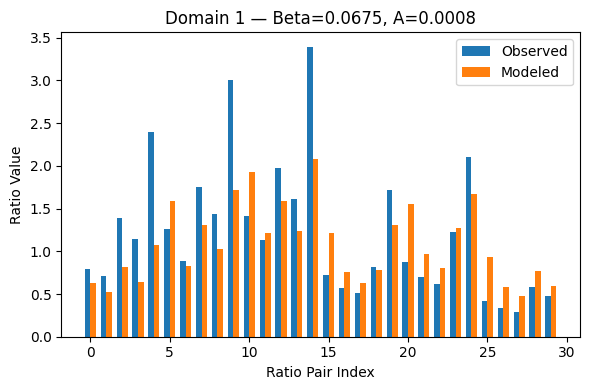

[Domain 2] Beta=0.0934, A=0.0001, Loss=0.004749


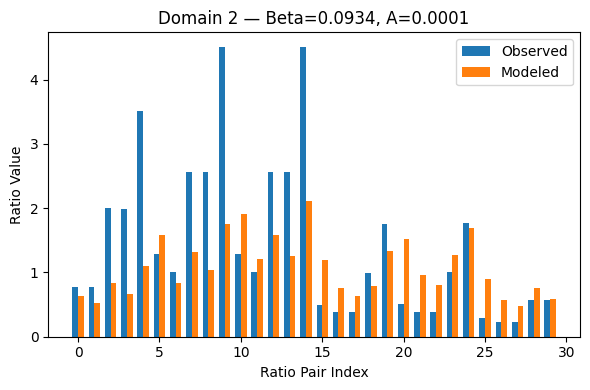

[Domain 3] Beta=0.0580, A=0.0691, Loss=0.001975


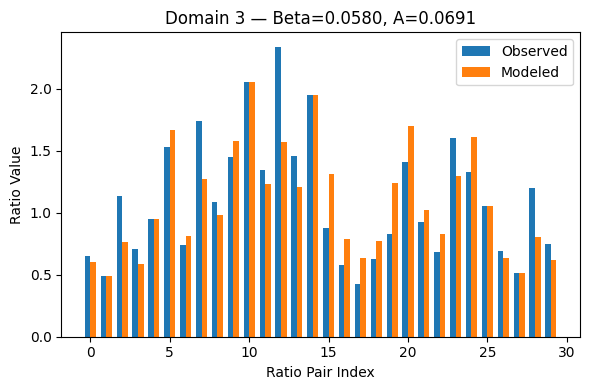

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize, Bounds, BFGS
from itertools import permutations

# ===============================================================
# 1. Data Setup
# ===============================================================
base_token = 0.66
N = 3 * base_token  # 'N' from your original context
x_vals = np.array([i * base_token for i in [1/3, 1/2, 1, 2, 3]])

# Each row in 'lyst' corresponds to a domain's L-values, i.e. 5 data points.
# We'll treat each row separately (each domain has its own parameters).
lyst = [
    # Domain: instr
    [
        2.262133190042021,  # third
        2.268651668846584,  # half
        2.24860813834489,   # one
        2.2374186036289854, # double
        2.2304256326869805  # triple
    ],
    # Domain: math
    [
        2.282574817052204,   # third
        2.255508926510795,   # half
        2.247996610369668,   # one
        2.23818165034097,    # double
        2.2381429227144665   # triple
    ],
    # Domain: code
    [
        2.311230037162437,   # third
        2.2747070035836745,  # half
        2.2549156492121742,  # one
        2.2251416028890385,  # double
        2.19535874342839     # triple
    ]
]

# ===============================================================
# 2. Define functions for Beta & A estimation via ratio approach
# ===============================================================

def difference_model(Ni, Nj, beta, A):
    """
    Returns (Ni + A)^(-beta) - (Nj + A)^(-beta).
    """
    return (Ni + A)**(-beta) - (Nj + A)**(-beta)

def ratio_model(Ni, Nj, Nk, Nm, beta, A):
    """
    Returns:
        [ (Ni + A)^(-beta) - (Nj + A)^(-beta) ] /
        [ (Nk + A)^(-beta) - (Nm + A)^(-beta) ]
    """
    num = difference_model(Ni, Nj, beta, A)
    den = difference_model(Nk, Nm, beta, A)
    return num / den

# ===============================================================
# 2a. Define Huber Loss
# ===============================================================
def huber_loss(r, delta=0.001):
    """
    Scalar Huber loss for residual 'r'.
    L_delta(r) = 0.5 * r^2                   if |r| <= delta
               = delta*(|r| - 0.5*delta)     if |r| >  delta
    """
    abs_r = abs(r)
    if abs_r <= delta:
        return 0.5 * r**2
    else:
        return delta*(abs_r - 0.5*delta)

# ===============================================================
# 3. Objective: Using Huber loss for ratio (or log-of-ratio) residuals
# ===============================================================
def multi_ratio_objective(ba, Lvals, Nvals, ratio_pairs, use_log_ratio=False,
                          use_huber=False, delta=1.0):
    """
    - If use_log_ratio=True, we measure difference between
      [log(L_i - L_j)/log(L_k - L_m)] vs. [log(model_num)/log(model_den)].
    - If use_log_ratio=False, we measure difference between
      (L_i - L_j)/(L_k - L_m) vs. model_num/model_den.

    - If use_huber=True, applies Huber loss to the residual.
      Otherwise, defaults to squared-error.
    """
    beta, A = ba
    total_loss = 0.0

    for ((i,j),(k,m)) in ratio_pairs:
        i0, j0 = i-1, j-1
        k0, m0 = k-1, m-1
        
        # Observed differences
        obs_num = Lvals[i0] - Lvals[j0]
        obs_den = Lvals[k0] - Lvals[m0]
        
        # Avoid near-zero denominators (observed)
        if abs(obs_den) < 1e-12:
            continue
        
        # Modeled differences
        mod_num = difference_model(Nvals[i0], Nvals[j0], beta, A)
        mod_den = difference_model(Nvals[k0], Nvals[m0], beta, A)

        # Avoid near-zero denominators (modeled)
        if abs(mod_den) < 1e-8:
            continue

        # Build the residual
        if use_log_ratio:
            # <-- MODIFIED: use ratio of logs, i.e. log(...) / log(...)

            # Skip if either portion is non-positive
            if (obs_num <= 0) or (obs_den <= 0) or (mod_num <= 0) or (mod_den <= 0):
                continue

            obs_ratio_log = np.log(obs_num) / np.log(obs_den)
            mod_ratio_log = np.log(mod_num) / np.log(mod_den)

            diff = obs_ratio_log - mod_ratio_log

        else:
            # Normal ratio approach
            obs_ratio = obs_num / obs_den
            mod_ratio = mod_num / mod_den

            diff = obs_ratio - mod_ratio

        # Accumulate either Huber loss or squared error
        if use_huber:
            total_loss += huber_loss(diff, delta=delta)
        else:
            total_loss += diff**2  # standard SSE

    return total_loss

def generate_all_ratio_pairs(base_pairs):
    """
    Generate all ordered ratio pairs from the base_pairs list,
    excluding pairs where numerator and denominator are identical.

    Parameters:
    - base_pairs: List of tuples, e.g., [(1,3), (1,4), ...]

    Returns:
    - List of tuples: [((i,j),(k,m)), ...]
    """
    all_perms = list(permutations(base_pairs, 2))
    return all_perms

# ===============================================================
# 4. Estimation routine
# ===============================================================
def estimate_beta_and_A(Lvals, Nvals,
                        use_log_ratio=False,
                        use_huber=True,
                        delta=1.0):
    """
    Estimate beta, A using:
    - ratio-based objective
    - optional ratio-of-logs approach
    - optional Huber loss
    """
    # Example ratio pairs (1-based):
    base_pairs = [
        (1, 3),
        (1, 4),
        (1, 5),
        (2, 4),
        (2, 5),
        (3, 5)
    ]

    # Generate all ordered permutations of the base pairs
    ratio_pairs = generate_all_ratio_pairs(base_pairs)

    # Remove any ratio_pair where numerator and denominator are identical
    ratio_pairs = [rp for rp in ratio_pairs if rp[0] != rp[1]]
    
    def obj(ba):
        return multi_ratio_objective(
            ba, Lvals, Nvals, ratio_pairs,
            use_log_ratio=use_log_ratio,
            use_huber=use_huber,
            delta=delta
        )

    # Bounds
    beta_lb = 0
    A_lb = 0
    A_ub = (2.0/3.0)*N  # from your context
    bounds = Bounds([beta_lb, A_lb], [np.inf, A_ub])

    # Initial guess
    init_guess = [0.45, 0.8]

    # Minimize
    res = minimize(
        obj,
        x0=init_guess,
        method='trust-constr',
        bounds=bounds,
        jac='2-point',
        hess=BFGS(),
        options={'verbose': 0, 'maxiter': 1000}
    )

    if res.success:
        return res.x[0], res.x[1], res.fun, ratio_pairs
    else:
        return None, None, None, ratio_pairs

# ===============================================================
# 5. Helper to plot ratio_data vs ratio_model for each domain
# ===============================================================
def plot_ratios(domain_index, beta, A, Lvals, Nvals, ratio_pairs):
    """
    For each ratio pair, compute the 'observed ratio' vs the
    'modeled ratio' at the final (beta, A). Then plot them
    as a side-by-side bar chart or scatter plot.
    """
    obs_list = []
    mod_list = []

    for ((i,j),(k,m)) in ratio_pairs:
        i0, j0 = i-1, j-1
        k0, m0 = k-1, m-1
        L_i, L_j = Lvals[i0], Lvals[j0]
        L_k, L_m = Lvals[k0], Lvals[m0]
        N_i, N_j = Nvals[i0], Nvals[j0]
        N_k, N_m = Nvals[k0], Nvals[m0]

        obs_num = (L_i - L_j)
        obs_den = (L_k - L_m)
        mod_num = difference_model(N_i, N_j, beta, A)
        mod_den = difference_model(N_k, N_m, beta, A)

        # Just for plotting, do the normal ratio (no log)
        if abs(obs_den) < 1e-8:
            continue
        obs_ratio = obs_num / obs_den

        if abs(mod_den) < 1e-8:
            continue
        mod_ratio = mod_num / mod_den

        obs_list.append(obs_ratio)
        mod_list.append(mod_ratio)

    # Plot side-by-side bar chart
    x_idx = np.arange(len(obs_list))
    width = 0.35

    plt.figure(figsize=(6,4))
    plt.bar(x_idx - width/2, obs_list, width=width, label='Observed')
    plt.bar(x_idx + width/2, mod_list, width=width, label='Modeled')

    plt.title(f"Domain {domain_index} — Beta={beta:.4f}, A={A:.4f}")
    plt.xlabel("Ratio Pair Index")
    plt.ylabel("Ratio Value")
    plt.legend()
    plt.tight_layout()
    plt.show()

# ===============================================================
# 6. Main Loop: Fit Beta & A, then Plot
# ===============================================================
if __name__ == "__main__":
    # Toggle these to see the effect of ratio-of-logs vs. raw ratio,
    # and the effect of Huber loss vs. squared-error.
    USE_LOG_RATIO = True      # <-- try switching to False to compare
    USE_HUBER_LOSS = True
    DELTA = 0.001 # Huber delta threshold

    for domain_index, Lvals_raw in enumerate(lyst, start=1):
        Lvals = np.array(Lvals_raw)
        
        # Estimate parameters
        beta_est, A_est, total_loss, ratio_pairs = estimate_beta_and_A(
            Lvals, 
            x_vals,
            use_log_ratio=USE_LOG_RATIO,
            use_huber=USE_HUBER_LOSS,
            delta=DELTA
        )

        if beta_est is None:
            print(f"[Domain {domain_index}] Beta/A fitting failed")
        else:
            print(f"[Domain {domain_index}] Beta={beta_est:.4f}, A={A_est:.4f}, Loss={total_loss:.6f}")

        # Plot the final result
        plot_ratios(domain_index, beta_est, A_est, Lvals, x_vals, ratio_pairs)

In [15]:
import random
li = [i + random.random() for i in li]


In [16]:
li

[3.140356118237711,
 2.687386420985796,
 3.0824456298797047,
 2.4125346242504166,
 2.8628166599412723]

In [1]:
import json
import random
from datasets import load_dataset
from tqdm import tqdm
from langdetect import detect, LangDetectException
from transformers import AutoTokenizer, AutoModelForCausalLM

# Set paths
base_path = '/mbz/users/liyuan/LLaMA-Factory'
model_path = f"{base_path}/checkpoints/Llama-3.1-8B-Instruct"
output_path = f"/mbz/users/liyuan/LLaMA-Factory/data/data_mixing/orca/orca.json"

# Load tokenizer and dataset
tokenizer = AutoTokenizer.from_pretrained(model_path)
from datasets import load_dataset

ds = load_dataset("Open-Orca/OpenOrca")

/mbz/users/liyuan/miniconda3/envs/myenv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
